<a href="https://colab.research.google.com/github/bhaskarpondugala/NASSCOM_AI_FDP/blob/main/NASSCOM_Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [3]:
# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [4]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)


T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


In [5]:
print(f'T ndim={T.ndim} shape={T.shape}')

T ndim=2 shape=(3, 4)


In [6]:
print('T + T:\n', T + T)

T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]


In [7]:
print('T.T (transpose -> shape', T.T.shape, '):\n', T.T)
print('T.reshape(2, 6):\n', T.reshape(2, 6))

T.T (transpose -> shape (4, 3) ):
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
T.reshape(2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


In [8]:
# Core imports for the whole lab
import numpy as np
import sympy as sp

x, y = sp.symbols('x y')      # symbolic variables we'll reuse
sp.init_printing()            # pretty-print symbolic math
np.random.seed(42)
print('Setup complete. SymPy', sp.__version__, '| NumPy', np.__version__)

Setup complete. SymPy 1.14.0 | NumPy 2.0.2


In [14]:
# 1A. NUMERICAL DERIVATIVE (finite difference)
# -----------------------------------------------------------

# The derivative is the slope: how much f changes for a tiny step h
def f(x):
    return x**2

h = 1e-6
slope_at_2 = (f(2 + h) - f(2)) / h
print('Numerical f\'(2):', round(slope_at_2, 4), ' (exact = 4)')

Numerical f'(2): 4.0  (exact = 4)


In [13]:
# 1B. SYMBOLIC DERIVATIVE (SymPy)
# -----------------------------------------------------------

expr = x**2
deriv = sp.diff(expr, x)          # differentiate w.r.t. x
print('d/dx (x**2) =', deriv)     # 2*x

# Evaluate the symbolic derivative at x = 3
print('Symbolic f\'(3) =', deriv.subs(x, 3))

d/dx (x**2) = 2*x
Symbolic f'(3) = 6


## 2. Symbolic Differentiation Example

In [15]:
new_expr = sp.sin(x) * sp.cos(x)
new_deriv = sp.diff(new_expr, x)
print(f'd/dx ({new_expr}) = {new_deriv}')

d/dx (sin(x)*cos(x)) = -sin(x)**2 + cos(x)**2


In [16]:
symbolic_deriv_at_2 = deriv.subs(x, 2)
print(f'Symbolic f\'(2) = {symbolic_deriv_at_2} (matches numerical derivative: {symbolic_deriv_at_2 == round(slope_at_2)})')

Symbolic f'(2) = 4 (matches numerical derivative: True)


In [18]:
def g(x):
    return x**3 + 2*x


In [19]:
h = 1e-6
slope_g_at_2 = (g(2 + h) - g(2)) / h
print(f'Numerical g\'(2): {round(slope_g_at_2, 4)} (exact = 14)')

Numerical g'(2): 14.0 (exact = 14)


### 3. Symbolic Derivative of `g(x)`

In [20]:
g_expr = x**3 + 2*x
g_deriv = sp.diff(g_expr, x)
print(f'd/dx ({g_expr}) = {g_deriv}')

d/dx (x**3 + 2*x) = 3*x**2 + 2


In [22]:
3. Evaluate the symbolic derivative at x = 2 and compare

symbolic_g_deriv_at_2 = g_deriv.subs(x, 2)
print(f'Symbolic g\'(2) = {symbolic_g_deriv_at_2} (matches numerical derivative: {symbolic_g_deriv_at_2 == round(slope_g_at_2)})')

Symbolic g'(2) = 14 (matches numerical derivative: True)


### 4. Plotting `g(x)` and its Derivative

In [23]:
# Convert symbolic expressions to numerical functions
g_numerical = sp.lambdify(x, g_expr, 'numpy')
g_deriv_numerical = sp.lambdify(x, g_deriv, 'numpy')

In [24]:
# Generate x values
x_vals = np.linspace(-5, 5, 400)

# Calculate y values for g(x) and g'(x)
y_g_vals = g_numerical(x_vals)
y_g_deriv_vals = g_deriv_numerical(x_vals)

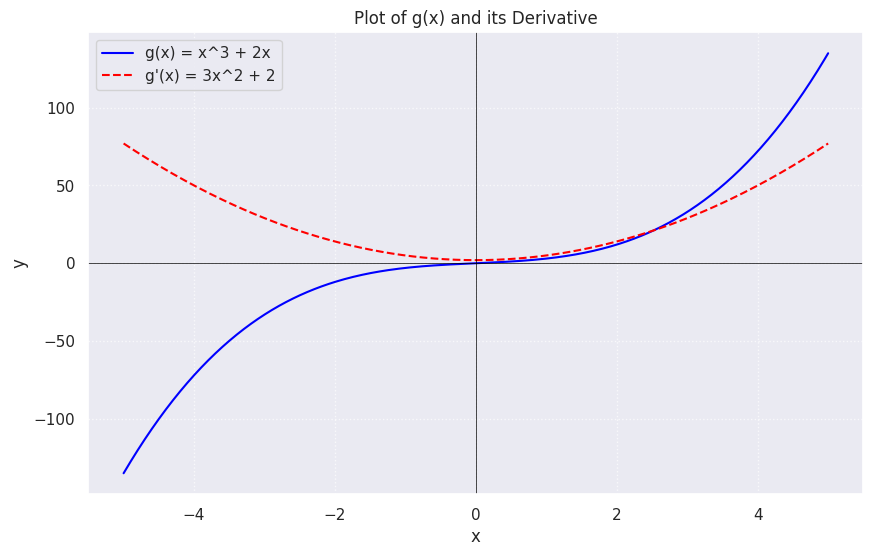

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_g_vals, label='g(x) = x^3 + 2x', color='blue')
plt.plot(x_vals, y_g_deriv_vals, label='g\'(x) = 3x^2 + 2', color='red', linestyle='--')

plt.title('Plot of g(x) and its Derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

In [27]:
# 2A. PARTIAL DERIVATIVES
# -----------------------------------------------------------

f2 = x**2 + 3*x*y + y**2

# A partial derivative differentiates ONE variable, holding others fixed
print('df/dx =', sp.diff(f2, x))     # 2*x + 3*y
print('df/dy =', sp.diff(f2, y))     # 3*x + 2*y


df/dx = 2*x + 3*y
df/dy = 3*x + 2*y


In [29]:
# 🔹 2B. THE GRADIENT (vector of partials)
# -----------------------------------------------------------

# The gradient stacks every partial derivative into one vector
grad = [sp.diff(f2, v) for v in (x, y)]
print('grad f =', grad)

# Evaluate the gradient at the point (x=1, y=2)
grad_at = [g.subs({x: 1, y: 2}) for g in grad]
print('grad f at (1, 2) =', grad_at)   # points in the steepest-ascent direction


grad f = [2*x + 3*y, 3*x + 2*y]
grad f at (1, 2) = [8, 7]


In [30]:
Compute dh/dx and dh/dy with sp.diff.

# Define a new symbolic function h(x, y)
h_expr = x**3 * y + sp.sin(x*y) + y**2

# Compute partial derivatives
dh_dx = sp.diff(h_expr, x)
dh_dy = sp.diff(h_expr, y)

print(f'h(x, y) = {h_expr}')
print(f'dh/dx = {dh_dx}')
print(f'dh/dy = {dh_dy}')

h(x, y) = x**3*y + y**2 + sin(x*y)
dh/dx = 3*x**2*y + y*cos(x*y)
dh/dy = x**3 + x*cos(x*y) + 2*y


In [31]:
# Assemble the gradient of h(x, y)
grad_h = [dh_dx, dh_dy]
print(f'grad h = {grad_h}')

grad h = [3*x**2*y + y*cos(x*y), x**3 + x*cos(x*y) + 2*y]


In [32]:
# Evaluate the gradient of h(x, y) at the point (x=2, y=0)
grad_h_at_point = [g_comp.subs({x: 2, y: 0}) for g_comp in grad_h]
print(f'grad h at (2, 0) = {grad_h_at_point}')

grad h at (2, 0) = [0, 10]


In [33]:
h2 = x**2 * y + sp.sin(y)

In [34]:
# Define h2 as a symbolic expression
h2_expr = x**2 * y + sp.sin(y)

# Compute partial derivatives
dh2_dx = sp.diff(h2_expr, x)
dh2_dy = sp.diff(h2_expr, y)

print(f'h2(x, y) = {h2_expr}')
print(f'dh2/dx = {dh2_dx}')
print(f'dh2/dy = {dh2_dy}')

h2(x, y) = x**2*y + sin(y)
dh2/dx = 2*x*y
dh2/dy = x**2 + cos(y)


In [35]:
grad_h2 = [dh2_dx, dh2_dy]
print(f'grad h2 = {grad_h2}')

grad h2 = [2*x*y, x**2 + cos(y)]


In [36]:
grad_h2_at_point = [g_comp.subs({x: 2, y: 0}) for g_comp in grad_h2]
print(f'grad h2 at (2, 0) = {grad_h2_at_point}')

grad h2 at (2, 0) = [0, 5]


In [38]:
# 3A. CHAIN RULE BY HAND vs SymPy
# -----------------------------------------------------------

# y = sin(x**2) is a composition: outer = sin(u), inner = u = x**2
# Chain rule:  dy/dx = cos(u) * du/dx = cos(x**2) * 2x
by_hand = sp.cos(x**2) * 2*x
by_sympy = sp.diff(sp.sin(x**2), x)

print('By hand :', by_hand)
print('By SymPy:', by_sympy)
print('Match?  ', sp.simplify(by_hand - by_sympy) == 0)

By hand : 2*x*cos(x**2)
By SymPy: 2*x*cos(x**2)
Match?   True


In [41]:
# 3B. CHAINING THREE FUNCTIONS
# -----------------------------------------------------------

# y = (3x + 1)**4  -> outer^4, inner (3x+1)
expr3 = (3*x + 1)**4
print('d/dx (3x+1)^4 =', sp.diff(expr3, x))   # 12*(3x+1)^3

d/dx (3x+1)^4 = 12*(3*x + 1)**3


In [43]:
# y = exp(x**2 + 1);  inner = x**2 + 1, inner' = 2x, outer' = exp(inner)

### 3C. Chain Rule with `exp(x**2 + 1)`

For the function $y = e^{(x^2 + 1)}$, we can identify the outer and inner functions:
*   Outer function: $f(u) = e^u$
*   Inner function: $u = g(x) = x^2 + 1$

The derivatives are:
*   $f'(u) = e^u$
*   $g'(x) = 2x$

Using the chain rule, $\frac{dy}{dx} = f'(g(x)) \cdot g'(x) = e^{(x^2 + 1)} \cdot 2x$.

In [44]:
expr_exp = sp.exp(x**2 + 1)

# By hand calculation (based on the explanation above)
by_hand_exp = 2 * x * sp.exp(x**2 + 1)

# By SymPy calculation
by_sympy_exp = sp.diff(expr_exp, x)

print('Expression : ', expr_exp)
print('By hand    : ', by_hand_exp)
print('By SymPy   : ', by_sympy_exp)
print('Match?     : ', sp.simplify(by_hand_exp - by_sympy_exp) == 0)

Expression :  exp(x**2 + 1)
By hand    :  2*x*exp(x**2 + 1)
By SymPy   :  2*x*exp(x**2 + 1)
Match?     :  True


### 3D. Chain Rule with `ln(sin(x))`

For the function $y = \ln(\sin(x))$, we can identify the outer and inner functions:
*   Outer function: $f(u) = \ln(u)$
*   Inner function: $u = g(x) = \sin(x)$

The derivatives are:
*   $f'(u) = \frac{1}{u}$
*   $g'(x) = \cos(x)$

Using the chain rule, $\frac{dy}{dx} = f'(g(x)) \cdot g'(x) = \frac{1}{\sin(x)} \cdot \cos(x) = \cot(x)$.

In [45]:
expr_ln_sin = sp.ln(sp.sin(x))

# By hand calculation (based on the explanation above)
by_hand_ln_sin = sp.cot(x)

# By SymPy calculation
by_sympy_ln_sin = sp.diff(expr_ln_sin, x)

print('Expression : ', expr_ln_sin)
print('By hand    : ', by_hand_ln_sin)
print('By SymPy   : ', by_sympy_ln_sin)
print('Match?     : ', sp.simplify(by_hand_ln_sin - by_sympy_ln_sin) == 0)

Expression :  log(sin(x))
By hand    :  cot(x)
By SymPy   :  cos(x)/sin(x)
Match?     :  True


In [48]:
# 4A. FORWARD PASS
# -----------------------------------------------------------

# Tiny toy problem: 4 samples, 3 input features, 5 hidden units, 1 output
X = np.random.randn(4, 3)
Y = np.random.randn(4, 1)
W1 = np.random.randn(3, 5) * 0.1
W2 = np.random.randn(5, 1) * 0.1

z1 = X @ W1                 # linear layer 1
h  = np.maximum(0, z1)      # ReLU activation
y_hat = h @ W2              # linear layer 2 (prediction)
loss = ((y_hat - Y) ** 2).mean()
print('Initial loss:', round(loss, 4))

Initial loss: 1.6936


In [50]:
# 🔹 4B. BACKWARD PASS (gradients via the chain rule)
# -----------------------------------------------------------

# Work backwards from the loss, one link at a time
dy   = 2 * (y_hat - Y) / Y.size      # d loss / d y_hat
dW2  = h.T @ dy                      # d loss / d W2
dh   = dy @ W2.T                     # d loss / d h
dz1  = dh * (z1 > 0)                 # ReLU gradient (1 where z1>0 else 0)
dW1  = X.T @ dz1                     # d loss / d W1

print('dW1 shape:', dW1.shape, '(matches W1)')
print('dW2 shape:', dW2.shape, '(matches W2)')

dW1 shape: (3, 5) (matches W1)
dW2 shape: (5, 1) (matches W2)


In [52]:
# 4C. ONE GRADIENT-DESCENT STEP SHOULD LOWER THE LOSS
# -----------------------------------------------------------

lr = 0.1
W1 -= lr * dW1               # step downhill
W2 -= lr * dW2

# Recompute the loss after the update
h_new = np.maximum(0, X @ W1)
loss_new = ((h_new @ W2 - Y) ** 2).mean()
print('Loss before:', round(loss, 4))
print('Loss after :', round(loss_new, 4), '-> should be lower')

Loss before: 1.6936
Loss after : 1.6524 -> should be lower


In [53]:
z1 = X @ W1                 # linear layer 1
h  = np.maximum(0, z1)      # ReLU activation
y_hat = h @ W2              # linear layer 2 (prediction)
loss = ((y_hat - Y) ** 2).mean()
print('Initial loss:', round(loss, 4))

Initial loss: 1.6524


In [54]:
# Work backwards from the loss, one link at a time
dy   = 2 * (y_hat - Y) / Y.size      # d loss / d y_hat
dW2  = h.T @ dy                      # d loss / d W2
dh   = dy @ W2.T                     # d loss / d h
dz1  = dh * (z1 > 0)                 # ReLU gradient (1 where z1>0 else 0)
dW1  = X.T @ dz1                     # d loss / d W1

print('dW1 shape:', dW1.shape, '(matches W1)')
print('dW2 shape:', dW2.shape, '(matches W2)')

dW1 shape: (3, 5) (matches W1)
dW2 shape: (5, 1) (matches W2)


In [55]:
# 4C. ONE GRADIENT-DESCENT STEP SHOULD LOWER THE LOSS (with lr = 0.05)
# -----------------------------------------------------------

lr = 0.05
W1 -= lr * dW1               # step downhill
W2 -= lr * dW2

# Recompute the loss after the update
h_new = np.maximum(0, X @ W1)
loss_new = ((h_new @ W2 - Y) ** 2).mean()
print('Loss before:', round(loss, 4))
print('Loss after :', round(loss_new, 4), '-> should be lower')

Loss before: 1.6524
Loss after : 1.6211 -> should be lower


In [57]:
Xb = np.random.randn(6, 4)
Yb = np.random.randn(6, 1)
Wa = np.random.randn(4, 8) * 0.1     # input -> hidden
Wb = np.random.randn(8, 1) * 0.1     # hidden -> output


In [58]:
z1_b = Xb @ Wa                # linear layer 1 for new data
h_b  = np.maximum(0, z1_b)     # ReLU activation for new data
y_hat_b = h_b @ Wb             # linear layer 2 (prediction) for new data
loss_b = ((y_hat_b - Yb) ** 2).mean()
print('Initial loss with new data:', round(loss_b, 4))

Initial loss with new data: 1.1706


In [59]:
dy_b = 2 * (y_hat_b - Yb) / Yb.size      # d loss / d y_hat for new data
dWb_new  = h_b.T @ dy_b                   # d loss / d Wb for new data
dh_b   = dy_b @ Wb.T                     # d loss / d h for new data
dz1_b  = dh_b * (z1_b > 0)               # ReLU gradient for new data (1 where z1_b>0 else 0)
dWa_new  = Xb.T @ dz1_b                    # d loss / d Wa for new data

print('dWa_new shape:', dWa_new.shape, '(matches Wa)')
print('dWb_new shape:', dWb_new.shape, '(matches Wb)')

dWa_new shape: (4, 8) (matches Wa)
dWb_new shape: (8, 1) (matches Wb)


In [60]:
lr_new = 0.05
Wa -= lr_new * dWa_new               # step downhill for Wa
Wb -= lr_new * dWb_new               # step downhill for Wb

# Recompute the loss after the update for the new data
h_new_b = np.maximum(0, Xb @ Wa)
loss_new_b = ((h_new_b @ Wb - Yb) ** 2).mean()
print('Loss before update (new data):', round(loss_b, 4))
print('Loss after update (new data):', round(loss_new_b, 4), '-> should be lower')

Loss before update (new data): 1.1706
Loss after update (new data): 1.1614 -> should be lower


In [62]:
# THE HESSIAN (matrix of second derivatives = curvature)
# -----------------------------------------------------------

f5 = x**2 + 3*x*y + y**2
H = sp.hessian(f5, (x, y))
print('Hessian of f:')
sp.pprint(H)        # [[2, 3], [3, 2]]

Hessian of f:
⎡2  3⎤
⎢    ⎥
⎣3  2⎦


In [65]:
f_new = x**4 + y**2
H_new = sp.hessian(f_new, (x, y))
print('Hessian of f = x**4 + y**2:')
sp.pprint(H_new)

Hessian of f = x**4 + y**2:
⎡    2   ⎤
⎢12⋅x   0⎥
⎢        ⎥
⎣  0    2⎦


In [64]:
# 5B. GRADIENT DESCENT ON A SIMPLE FUNCTION
# -----------------------------------------------------------

# Minimise f(x) = (x - 4)**2, whose minimum is at x = 4.
# Update rule:  x <- x - lr * f'(x),  with f'(x) = 2*(x - 4)
xv = 0.0          # starting point
lr = 0.2
for step in range(15):
    grad = 2 * (xv - 4)        # the derivative
    xv = xv - lr * grad        # step against the gradient
print('Converged x:', round(xv, 3), ' (true minimum = 4)')

Converged x: 3.998  (true minimum = 4)


In [66]:
# Minimise f(x) = (x - 7)**2, whose minimum is at x = 7.
# Update rule:  x <- x - lr * f'(x),  with f'(x) = 2*(x - 7)
xv_new = 0.0          # starting point
lr_new = 0.1

for step_new in range(20):
    grad_new = 2 * (xv_new - 7)        # the derivative
    xv_new = xv_new - lr_new * grad_new        # step against the gradient

print('Final x:', round(xv_new, 3))

Final x: 6.919
